In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define the transformation for resizing images to 256x256
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Download the CelebA dataset
celeba_dataset = datasets.CelebA(root='data', split='train', download=True, transform=transform)

# Create a DataLoader for easy batching
celeba_loader = DataLoader(celeba_dataset, batch_size=64, shuffle=True)

# Example of accessing a batch
images, labels = next(iter(celeba_loader))
print(images.shape)  # Should be [batch_size, 3, 256, 256]

Files already downloaded and verified
torch.Size([64, 3, 256, 256])


In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import save_image
from torchvision import transforms
from model import MNISTDiffusion, CelebADiffusion
from train_mnist import create_mnist_dataloaders
from tqdm import tqdm


# Load MNIST model checkpoint and set up device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cuda


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"

In [19]:
from diffusers import DDPMPipeline

model_id = "google/ddpm-celebahq-256"

# load model and scheduler
ddpm = DDPMPipeline.from_pretrained(model_id, device_map="auto")  # you can replace DDPMPipeline with DDIMPipeline or PNDMPipeline for faster inference

print(ddpm.unet)
# run pipeline in inference (sample random noise and denoise)
# image = ddpm()

/home/mpsenka/miniconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
diffusion_pytorch_model.safetensors not found
Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00,  2.37it/s]

UNet2DModel(
  (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0-1): 2 x DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv1): LoRACompatibleConv(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): LoRACompatibleLinear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): LoRACompatibleConv(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0

In [8]:
print(image)

ImagePipelineOutput(images=[<PIL.Image.Image image mode=RGB size=256x256 at 0x770EFC3FBD00>])


In [16]:
from torchvision import transforms
pil_image = image.images[0]
tensor_image = transforms.ToTensor()(pil_image)

IndexError: list index out of range

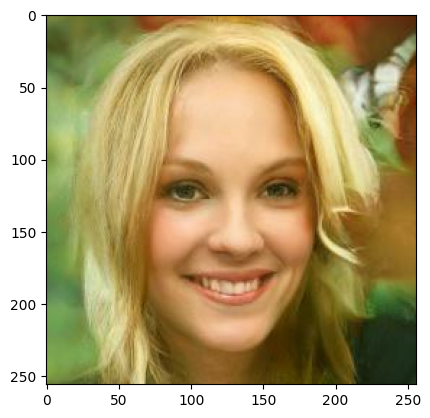

In [17]:
# display tensor image
plt.imshow(tensor_image.permute(1, 2, 0).numpy())

In [ ]:

ckpt_path = "best_model.pt"

# MNIST Diffusion Model Parameters
in_channels = 1
time_embedding_dim = 256
timesteps = 1000
base_dim = 64
dim_mults = [2, 4]

# Instantiate the model
model = MNISTDiffusion(
    image_size=28,
    in_channels=in_channels,
    timesteps=timesteps,
    time_embedding_dim=time_embedding_dim,
    base_dim=base_dim,
    dim_mults=dim_mults,
)

# Load the trained model weights
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model"])
model = model.to(device)
model.eval()

In [2]:
ckpt_path = "model/checkpoints/unet_ckpt_990.pkl"
checkpoint = torch.load(ckpt_path)
model = CelebADiffusion().to(device)
model.load_state_dict(checkpoint['model_state_dict'])

In [11]:
images.min()

tensor(-1.0039, device='cuda:0')

In [12]:
images = model.sampling(4)
# rescale
images = (images - images.min()) / (images.max() - images.min())
images = images.cpu()
images = images.detach().numpy()
images = np.transpose(images, (0, 2, 3, 1))

In [8]:
print(images)

[[[[ 4.12464142e-04  5.56409359e-04 -5.50866127e-04]
   [ 5.97298145e-04  1.95980072e-04 -8.02218914e-04]
   [ 4.63455915e-04  1.09076500e-05 -7.29084015e-04]
   ...
   [ 1.62482262e-04 -8.17179680e-05 -7.63595104e-04]
   [-5.32865524e-05 -1.72436237e-04 -9.28580761e-04]
   [ 5.00798225e-04  1.77949667e-04 -8.35061073e-04]]

  [[ 9.20414925e-04 -2.25305557e-05 -7.33315945e-04]
   [ 5.18560410e-04  1.31517649e-04 -6.08861446e-04]
   [ 3.10510397e-04  1.40309334e-04 -7.71701336e-04]
   ...
   [ 2.33083963e-04 -1.65045261e-04 -8.49902630e-04]
   [ 2.25603580e-04 -1.86502934e-04 -7.50541687e-04]
   [ 3.68446112e-04 -2.26140022e-04 -7.37369061e-04]]

  [[ 5.98847866e-04  2.45094299e-04 -8.32796097e-04]
   [ 4.98414040e-04  2.44855881e-04 -7.57396221e-04]
   [ 3.86089087e-04  2.10911036e-04 -7.74323940e-04]
   ...
   [ 2.33799219e-04 -1.07049942e-04 -9.90211964e-04]
   [ 1.83790922e-04 -9.06586647e-05 -8.40008259e-04]
   [ 3.60071659e-04 -1.46508217e-04 -7.61628151e-04]]

  ...

  [[ 2.29886

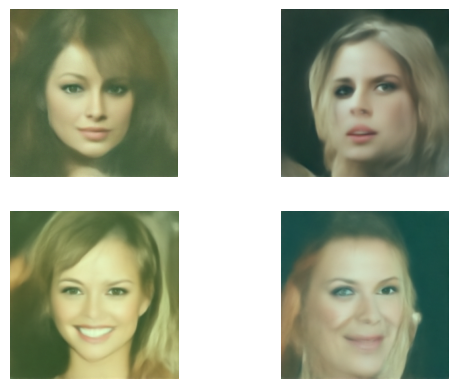

In [13]:
# display images. notes is a tensor os shape (4,3,256,256). Also needs to send to cpu

# images = (images + 1) / 2
fig, axes = plt.subplots(2, 2)
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.axis('off')
plt.show()


In [31]:
# Get a random MNIST image from the test set
_, test_dataloader = create_mnist_dataloaders(batch_size=1)
image, _ = next(iter(test_dataloader))

image2, _ = next(iter(test_dataloader))

# halfway convex interpolation

# image = 0.8 * image + 0.2 * image2

image = image.to(device)

In [39]:

# Unnormalize the image for visualization
inv_normalizer = transforms.Normalize([-1.0], [2.0])
unnormalized_image = inv_normalizer(image)

# Parameters
N = 100  # Number of Gaussian samples
σ = 0.1  # Standard deviation of Gaussian noise
timesteps = 1000  # Total number of timesteps

# List to store total errors for each timestep
total_errors = []

# Compute errors for timesteps from 0 to timesteps
t_values = torch.arange(0, timesteps, device=device)

for t in tqdm(t_values):
    t = t.unsqueeze(-1)
    t_batch = t.expand(N)

    # Generate N Gaussian noise samples of variance σ^2
    z_samples = torch.normal(mean=0.0, std=σ, size=(N, *image.shape[1:]), device=device)

    # Expand image to batch size N
    image_batch = image.expand(N, *image.shape[1:])

    # Create noisy images
    noisy_images = image_batch + z_samples

    with torch.no_grad():
        # Compute model outputs for the noisy images at time t
        model_outputs = model.model(noisy_images, t_batch)

    # Compute squared L2 norms of the differences for each sample
    errors = (noisy_images + model_outputs).pow(2).sum()  # Shape: (N,)

    # Sum over N samples
    total_error = errors.sum().item()

    total_errors.append(total_error)

100%|██████████| 1000/1000 [00:10<00:00, 94.24it/s]


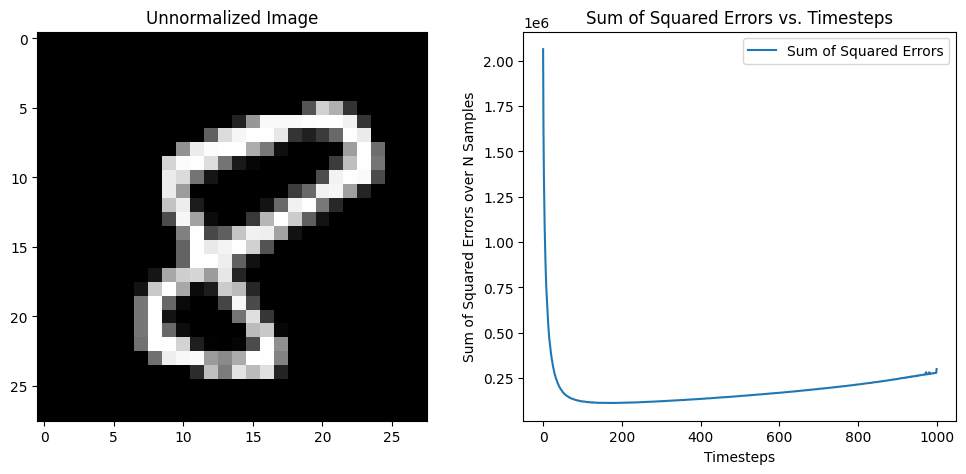

In [40]:
# Plot the image and the total errors
plt.figure(figsize=(10, 5))

# Show the unnormalized image
plt.subplot(1, 2, 1)
plt.imshow(unnormalized_image[0].cpu().numpy().squeeze(), cmap='gray')
plt.title('Unnormalized Image')

# Plot the total errors
plt.subplot(1, 2, 2)
plt.plot(t_values.cpu().numpy(), total_errors, label='Sum of Squared Errors')
plt.xlabel("Timesteps")
plt.ylabel("Sum of Squared Errors over N Samples")
plt.title("Sum of Squared Errors vs. Timesteps")


# Add a legend
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

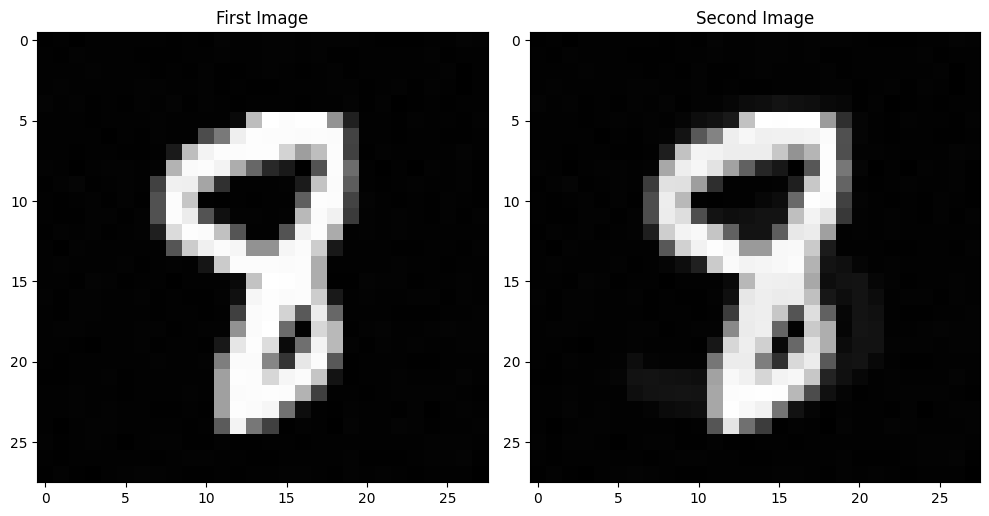

In [5]:
# load first_image_1.pt and second_image_1.pt
image1 = torch.load('first_image_0.pt')
image2 = torch.load('second_image_0.pt')
# display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image1[0].detach().cpu().numpy().squeeze(), cmap='gray')
plt.title('First Image')
plt.subplot(1, 2, 2)
plt.imshow(image2[0].detach().cpu().numpy().squeeze(), cmap='gray')
plt.title('Second Image')
plt.tight_layout()
plt.show()